In [1]:
import SZpack as SZ
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy import units as u
import astropy.constants as const

In [ ]:
# Setting some preliminary values for our calculations.
params = SZ.parameters()
params.set_x_array(0.1,15,500)    # This generates a logspaced array for xcmb of 100 points between 0.1 and 14
params.betao = 1.241e-3                # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params.betao = 0                # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params.muo = 0.0                  # Cosine of line-of-sight to the observers velocity. Angle measured in the observer frame
params.betac = 0/3e5               # Peculiar velocity of cluster with respect to CMB frame (betao = v/c)
params.muc = 0.3                  # Cosine of cluster velocity to the line-of-sight in the CMB rest frame
params.Te = 15                  # Electron temperature in keV
params.Dtau = 0.01             # The optical depth (must be > 0)
params.check_values()             # A function to check that the values set are valid.
params.runmode = "full"      # We will discuss this setting more later in this document.

params_tsz_20keV = SZ.parameters()
params_tsz_20keV.set_x_array(0.1,15,500)    # This generates a logspaced array for xcmb of 150 points between 0.1 and 14
params_tsz_20keV.betao = 1.241e-3                # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params_tsz_20keV.muo = 0.0                  # Cosine of line-of-sight to the observers velocity. Angle measured in the observer frame
params_tsz_20keV.betac = 0/3e5               # Peculiar velocity of cluster with respect to CMB frame (betao = v/c)
params_tsz_20keV.muc = 0.3                  # Cosine of cluster velocity to the line-of-sight in the CMB rest frame
params_tsz_20keV.Te = 15                 # Electron temperature in keV
params_tsz_20keV.Dtau = 0.01                 # The optical depth (must be > 0)
params_tsz_20keV.check_values()             # A function to check that the values set are valid.
params_tsz_20keV.runmode = "full"      # We will discuss this setting more later in this document.

params_ksz = SZ.parameters()
params_ksz.set_x_array(0.1,15,500)
params_ksz.betao = 1.241e-3
params_ksz.muo = 0.0
params_ksz.betac = 1000/3e5
params_ksz.muc = 0.3
params_ksz.Te = 1e-19
params_ksz.Dtau = 0.01
params_ksz.check_values()
params_ksz.runmode = "full"

In [ ]:
nonRel = SZ.compute_non_relativistic(params, DI=True) # The nonrelativistic signal
combo_tsz = SZ.compute_combo(params,DI=True)
combo_tsz_20keV = SZ.compute_combo(params_tsz_20keV,DI=True)
combo_ksz = SZ.compute_combo(params_ksz,DI=True)

In [ ]:
# A fully labelled graph to demonstrate what these later graphs will be showing.
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=32)

fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

ax2.plot(params.nucmb, np.zeros(params.gridpoints),'k',alpha=0)  #Twinning the nu values to the x values
ax2.axhline(y=0,c='k',ls='--')
ax1.plot(params.xcmb, nonRel, label='tSZ (non-relativistic)', color='C0', linewidth=2)  
ax1.plot(params.xcmb, combo_tsz_20keV, label=r'tSZ,r ($T_{\rm e}$ = 15 keV)', color='C1', linewidth=2)
ax1.plot(params_ksz.xcmb, combo_ksz, label='kSZ (1000 km/s)', color='C2', linewidth=2)

ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
ax2.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('Spectral distortion, $\Delta I$ (MJy/sr)')
# ax1.set_ylim(-0.15, 0.2)

ax1.legend(edgecolor='black', fontsize=20, fancybox=0, shadow=0, frameon=1, loc='lower right')

for axs in [ax1,ax2]:
    for axis in ['top','bottom','left','right']:
        axs.spines[axis].set_linewidth(1.2)
    axs.tick_params(which='both', width=1.2)
    axs.tick_params(which='major', length=7)
    axs.tick_params(which='minor', length=4)

act_freq = [98, 150, 220]
planck_freq = [30, 44, 70, 100, 143, 217, 353, 545]
marker_y = 0.58

for freq in act_freq:
    ax2.plot(freq, marker_y, 'o', color='blue', label='ACT maps' if freq == act_freq[0] else "", alpha=0.4)
for freq in planck_freq:
    ax2.plot(freq, marker_y, 's', color='green', label='Planck maps' if freq == planck_freq[0] else "", alpha=0.4)

ax1.set_xlim(0,params.xcmb[-1])
ax2.set_xlim(0,params.nucmb[-1])

ax2.set_xticks(np.arange(0, 1000, 200))
ax1.set_yticks(np.arange(-0.4, 0.7, 0.2))
ax1.set_xticks(np.arange(0, 16, 2))

handles, labels = ax2.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))

ax2.axhline(y=0,c='k',ls=':')
ax2.axvline(x=217,c='k',ls=':')  # A vertical line to show the null of the non-relativistic SZ signal

ax2.legend(unique_labels.values(), 
           unique_labels.keys(),
           edgecolor='black',   
           fontsize=20, 
           fancybox=0, 
           shadow=0, 
           frameon=True, 
           loc='upper right', 
           ncol=1)

# plt.text(600, .4, 'The markers show the frequency \nchannels we used for this work.', 
#          fontsize=26, color='k')

plt.tight_layout()
plt.savefig('../plots/szcompare.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
from astropy.io import fits
data = fits.getdata("/home/gill/Downloads/0921670101/4424_0921670101/4424_0921670101_SCX00000P5S.FIT")

print("Data shape:", data.shape)

# plot the data
plt.figure(figsize=(10, 7))
plt.imshow(data, cmap='gray', origin='lower')
plt.colorbar(label='Intensity')
plt.title('FITS Image Data')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.tight_layout()
plt.show()

In [ ]:
data.shape

In [ ]:
params.calc_The

In [ ]:
theta_e = const.k_B.to(u.kg * u.m**2 / u.s**2 / u.K) * params.Te * 10**3 * u.K / const.m_e / const.c**2

print(theta_e)

In [ ]:
const.k_B.to(u.kg * u.m**2 / u.s**2 / u.K)

In [ ]:
theta_e = params.Te * u.keV / (const.m_e * const.c**2).to(u.keV)

print(theta_e)

In [ ]:
The = k Te / me c^2

In [ ]:
e_me = const.m_e * const.c**2 

e_me.to(u.keV)

In [ ]:
# Setting some preliminary values for our calculations.
params = SZ.parameters()
params.set_x_array(0.1,15,500)    # This generates a logspaced array for xcmb of 100 points between 0.1 and 14
params.betao = 1.241e-3                # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params.betao = 0                # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params.muo = 0.0                  # Cosine of line-of-sight to the observers velocity. Angle measured in the observer frame
params.betac = 0/3e5               # Peculiar velocity of cluster with respect to CMB frame (betao = v/c)
params.muc = 0.3                  # Cosine of cluster velocity to the line-of-sight in the CMB rest frame
params.Te = 20                  # Electron temperature in keV
params.Dtau = 0.01             # The optical depth (must be > 0)
params.check_values()             # A function to check that the values set are valid.
params.runmode = "full"      # We will discuss this setting more later in this document.

In [ ]:
params.calc_The

In [ ]:
0.01956951336745513 * 2

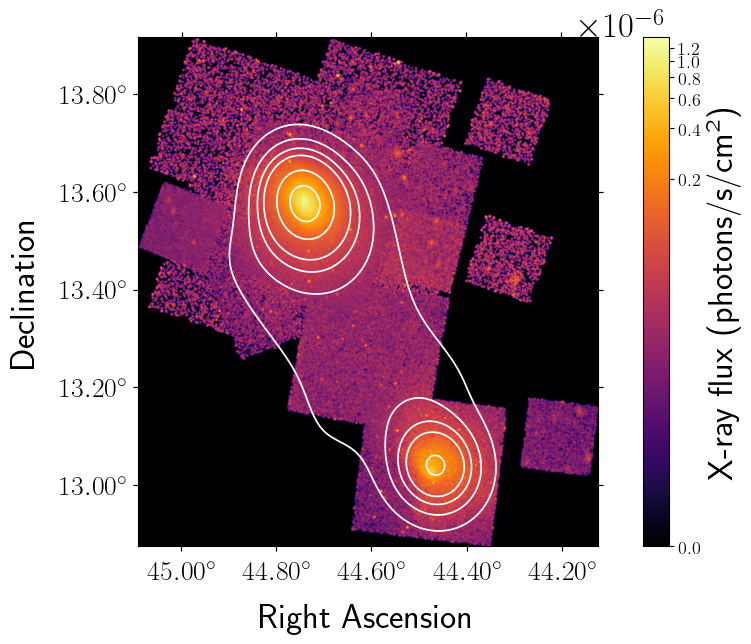

In [139]:
from astropy.wcs import WCS
from matplotlib.colors import LogNorm
from pixell import enmap
from astropy.visualization import (ZScaleInterval,
                                    PercentileInterval,
                                    MinMaxInterval,
                                    ImageNormalize,
                                    simple_norm)

# latex font sans-serif
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=25)

chandra = fits.getdata("/home/gill/Downloads/broad_flux.img.gz")

# smooth the chandra image with a Gaussian kernel
from scipy.ndimage import gaussian_filter
chandra = gaussian_filter(chandra, sigma=2)

# Load the WCS information from the FITS header
header = fits.getheader("/home/gill/Downloads/broad_flux.img.gz")
wcs = WCS(header)

# Handle zero/negative values for log normalization
# Add small positive value to avoid log(0) issues
norm = LogNorm()
norm = ImageNormalize(chandra, interval=ZScaleInterval())
norm = simple_norm(chandra, 'log')

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection=wcs)

# Plot the image
im = ax.imshow(chandra, cmap='inferno', origin='lower', norm=norm)

# ax in degrees
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

# model f90
f90_model = enmap.read_map("/home/gill/research/ACT/paper/models/indiv/total_model_all_three_systems_small_map/models/bridge_indv_98_pa5_model_uK.fits")

# Get the WCS from the f90_model
f90_wcs = f90_model.wcs

sigma = np.std(f90_model)
contour_levels = np.array([-12, -8, -5, -4, -3, -2]) * sigma
ax.contour(f90_model, levels=contour_levels, colors='white', linewidths=1.25, 
           linestyles='solid',
           alpha=1, transform=ax.get_transform(f90_wcs))

# Set coordinate labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

# Add colorbar
# smaller tick font size of the colorbar

cbar = plt.colorbar(im, ax=ax, label='X-ray flux (photons/s/cm²)', orientation='vertical')
cbar.ax.tick_params(labelsize=13)
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig('../plots/chandra_sz.pdf', dpi=600, bbox_inches='tight')
plt.show()


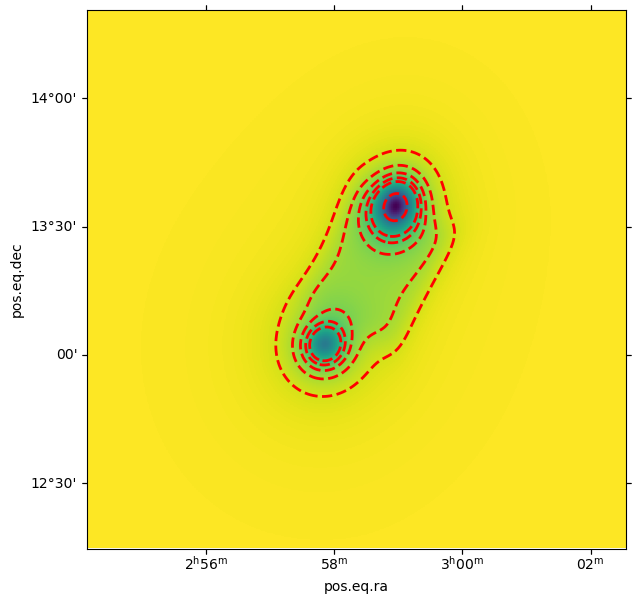

In [ ]:
# plot the model on the image
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection=f90_wcs)
# Plot the image
im = ax.imshow(f90_model, cmap='viridis', origin='lower')
# plot contours from the model on the image in terms of sigma 

# Calculate standard deviation of the model
sigma = np.std(f90_model)
contour_levels = np.array([-10, -5, -4, -3, -2, -1]) * sigma
ax.contour(f90_model, levels=contour_levels, colors='red', linewidths=2, 
           alpha=1, transform=ax.get_transform(f90_wcs))